In [1]:
import pandas as pd

In [6]:
dataset=pd.read_csv("RND.csv")
print(dataset)

   R&D      Spend  Administration  Marketing Spend       State     Profit
0    0  165349.20       136897.80        471784.10     Newyork  192261.83
1    1  162597.70       151377.59        443898.53  California  191792.06
2    2  153441.51       101145.55        407934.54     Florida  191050.39
3    3  144372.41       118671.85        383199.62     Newyork  182901.99
4    4  142107.34        91391.77        366168.42     Florida  166187.94
5    5  131876.90        99814.71        362861.36     newyork  156991.12
6    6  134615.46       147198.87        127716.82  California  156122.51
7    7  130298.13       145530.06        323876.68     Florida  155752.60
8    8  120542.52       148718.95        311613.29     Newyork  152211.77
9    9  123334.88       108679.17        304981.62  California  149759.96


In [7]:
dataset=pd.get_dummies(dataset,drop_first=True)
print(dataset)

   R&D      Spend  Administration  Marketing Spend     Profit  State_Florida  \
0    0  165349.20       136897.80        471784.10  192261.83          False   
1    1  162597.70       151377.59        443898.53  191792.06          False   
2    2  153441.51       101145.55        407934.54  191050.39           True   
3    3  144372.41       118671.85        383199.62  182901.99          False   
4    4  142107.34        91391.77        366168.42  166187.94           True   
5    5  131876.90        99814.71        362861.36  156991.12          False   
6    6  134615.46       147198.87        127716.82  156122.51          False   
7    7  130298.13       145530.06        323876.68  155752.60           True   
8    8  120542.52       148718.95        311613.29  152211.77          False   
9    9  123334.88       108679.17        304981.62  149759.96          False   

   State_Newyork  State_newyork  
0           True          False  
1          False          False  
2          False 

In [8]:
dataset.columns

Index(['R&D', 'Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_Newyork', 'State_newyork'],
      dtype='object')

In [9]:
independent=dataset[['R&D', 'Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_Newyork', 'State_newyork']]
print(independent)

   R&D      Spend  Administration  Marketing Spend  State_Florida  \
0    0  165349.20       136897.80        471784.10          False   
1    1  162597.70       151377.59        443898.53          False   
2    2  153441.51       101145.55        407934.54           True   
3    3  144372.41       118671.85        383199.62          False   
4    4  142107.34        91391.77        366168.42           True   
5    5  131876.90        99814.71        362861.36          False   
6    6  134615.46       147198.87        127716.82          False   
7    7  130298.13       145530.06        323876.68           True   
8    8  120542.52       148718.95        311613.29          False   
9    9  123334.88       108679.17        304981.62          False   

   State_Newyork  State_newyork  
0           True          False  
1          False          False  
2          False          False  
3           True          False  
4          False          False  
5          False           True  
6 

In [10]:
dependent=dataset[["Profit"]] 
print(dependent)

      Profit
0  192261.83
1  191792.06
2  191050.39
3  182901.99
4  166187.94
5  156991.12
6  156122.51
7  155752.60
8  152211.77
9  149759.96


In [12]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(independent, dependent, test_size=0.30,random_state=0)

In [72]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson',splitter='random')
regressor=regressor.fit(x_train,y_train)

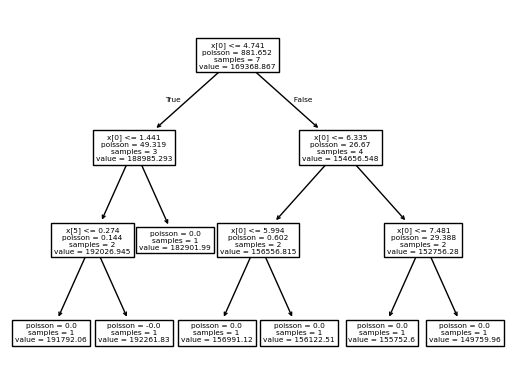

In [73]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [74]:
y_pred=regressor.predict(x_test) 
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
print(r_score)

0.5455033337097461
